# 04 · Enron spam — LLM-разметка (плоский JSONL)

Выход: `data/interim/annotated/enron_spam_annotated.jsonl`  
Выборка: `block_ab/samples/enron_spam_stratified.jsonl` (стратификация по subset × длина × URL × proxy).

Формат строки: исходные поля + `scenario_family` + `annotation_confidence` + `annotation_model`.


In [1]:
RANDOM_SEED = 42
N_ENRON_SPAM_UNIQUE = 1200
BATCH_SIZE = 12
SLEEP_SEC = 2.5
MAX_NEW_THIS_RUN = 80
ANNOTATION_MODEL = "openai/gpt-4o-mini"



In [2]:
import importlib.util
import json
import os
import time
from datetime import datetime, timezone
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI, APIError, RateLimitError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
from tqdm.auto import tqdm

def _find_v2_root() -> Path:
    candidate = Path(globals().get("__vsc_ipynb_file__", globals().get("__file__", "."))).resolve()
    for p in [candidate, *candidate.parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    raise RuntimeError("Cannot find v2/ project root")

V2_ROOT = _find_v2_root()
RAW_DIR = V2_ROOT / "data" / "raw" / "collected"
INTERIM = V2_ROOT / "data" / "interim" / "annotated"
BLOCK_AB = INTERIM / "block_ab"
SAMP_DIR = BLOCK_AB / "samples"
OUT_FLAT = INTERIM / "enron_spam_annotated.jsonl"
spec = importlib.util.spec_from_file_location("_ann_common", V2_ROOT / "notebooks" / "02_dataset_design" / "_ann_common.py")
ac = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ac)
load_dotenv(V2_ROOT / ".env" if (V2_ROOT / ".env").exists() else None)
api_key = os.environ.get("OPENROUTER_API_KEY", "")
if not api_key:
    raise EnvironmentError("OPENROUTER_API_KEY missing")
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=api_key)
print("OUT_FLAT =", OUT_FLAT)



OUT_FLAT = /Users/askar/projects/antifraud-deepfake-detection/v2/data/interim/annotated/enron_spam_annotated.jsonl


In [3]:
enron_all = ac.load_jsonl(RAW_DIR / "enron.jsonl")
enron_spam = [r for r in enron_all if r.get("label") == "spam"]

def build_enron_spam_sample():
    uniq = ac.dedupe_records_by_text_sha(enron_spam)
    rows = []
    for r in uniq:
        txt = r.get("text") or ""
        rows.append({**r, "_stratum_subset": r.get("subset", ""), "_stratum_wc": ac.wc_bin(ac.wc(txt)),
            "_stratum_url": str(bool(r.get("has_url"))), "_stratum_proxy": ac.proxy_bucket_spam(txt)})
    df = pd.DataFrame(rows)
    picked = ac.stratified_sample_df(df, N_ENRON_SPAM_UNIQUE, ["_stratum_subset", "_stratum_wc", "_stratum_url", "_stratum_proxy"], RANDOM_SEED)
    return picked.drop(columns=[c for c in picked.columns if c.startswith("_stratum_")]).to_dict("records")

sample = ac.ensure_sample(SAMP_DIR / "enron_spam_stratified.jsonl", build_enron_spam_sample)
print("n=", len(sample))



n= 1200


In [4]:
SPAM_EMAIL_CLASSES = '''One "category": phishing_email | candidate_419_or_advance_fee | promo_marketing_email | generic_spam_nonphishing | malware_or_attachment_lure | unclear_other. Booleans: has_financial_pretence, has_credentials_request, has_reward_or_prize, has_confidentiality_appeal, core_candidate. confidence: high|medium|low'''

def wrap(r):
    subj = (r.get("subject") or "").strip()
    body = (r.get("text") or "").strip()
    return [
        {"role": "system", "content": "Annotate Enron-Spam email (label=spam). " + SPAM_EMAIL_CLASSES + " JSON: category, confidence, booleans."},
        {"role": "user", "content": f"Subject: {subj}\n\nBody:\n{body}"},
    ]
OK = {"phishing_email", "candidate_419_or_advance_fee", "promo_marketing_email", "generic_spam_nonphishing", "malware_or_attachment_lure", "unclear_other"}
def val(d):
    c = d.get("category", "unclear_other")
    if c not in OK: c = "unclear_other"
    conf = d.get("confidence", "low")
    if conf not in {"high","medium","low"}: conf = "low"
    b = bool
    return {"category": c, "confidence": conf, "has_financial_pretence": b(d.get("has_financial_pretence")), "has_credentials_request": b(d.get("has_credentials_request")), "has_reward_or_prize": b(d.get("has_reward_or_prize")), "has_confidentiality_appeal": b(d.get("has_confidentiality_appeal")), "core_candidate": b(d.get("core_candidate"))}

@retry(retry=retry_if_exception_type((RateLimitError, APIError)), wait=wait_exponential(multiplier=2, min=2, max=45), stop=stop_after_attempt(6))
def call_json(msgs):
    return json.loads(client.chat.completions.create(model=ANNOTATION_MODEL, messages=msgs, response_format={"type":"json_object"}, temperature=0, max_tokens=256).choices[0].message.content)



In [5]:
idx = ac.load_flat_annotation_index(OUT_FLAT)
pending = [r for r in sample if ac.md5_text_key(r.get("text","")) not in idx]
print("pending", len(pending))
batch_i = 0
for r in tqdm(pending[:MAX_NEW_THIS_RUN], desc="enron_spam"):
    try:
        a = val(call_json(wrap(r)))
    except Exception as e:
        a = val({}); a["_error"] = str(e)[:200]
    ts = datetime.now(timezone.utc).isoformat()
    ex = {k: a[k] for k in ("core_candidate","has_financial_pretence","has_credentials_request","has_reward_or_prize","has_confidentiality_appeal") if k in a}
    if "_error" in a: ex["_error"] = a["_error"]
    flat = ac.make_flat_record(r, scenario_family=a["category"], annotation_confidence=a["confidence"], annotation_model=ANNOTATION_MODEL, annotated_at=ts, extra=ex)
    ac.append_jsonl(OUT_FLAT, flat)
    idx[ac.md5_text_key(r.get("text",""))] = flat
    batch_i += 1
    if batch_i >= BATCH_SIZE:
        batch_i = 0
        time.sleep(SLEEP_SEC)
print("total flat", len(ac.load_flat_annotation_index(OUT_FLAT)))



pending 1200


enron_spam:   0%|          | 0/80 [00:00<?, ?it/s]

total flat 80


Total annotated: 80

Category distribution:
scenario_family
promo_marketing_email           57
generic_spam_nonphishing        14
phishing_email                   5
candidate_419_or_advance_fee     4
Name: count, dtype: int64

Confidence distribution:
annotation_confidence
high      51
medium    28
low        1
Name: count, dtype: int64

Flag counts (True per flag):
core_candidate                : 0
has_financial_pretence        : 0
has_credentials_request       : 0
has_reward_or_prize           : 0
has_confidentiality_appeal    : 0


/var/folders/22/l60tvhln5rlbvshvwggtvlc40000gn/T/ipykernel_88079/4242429482.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.index, y=cat_counts.values, palette="tab10")


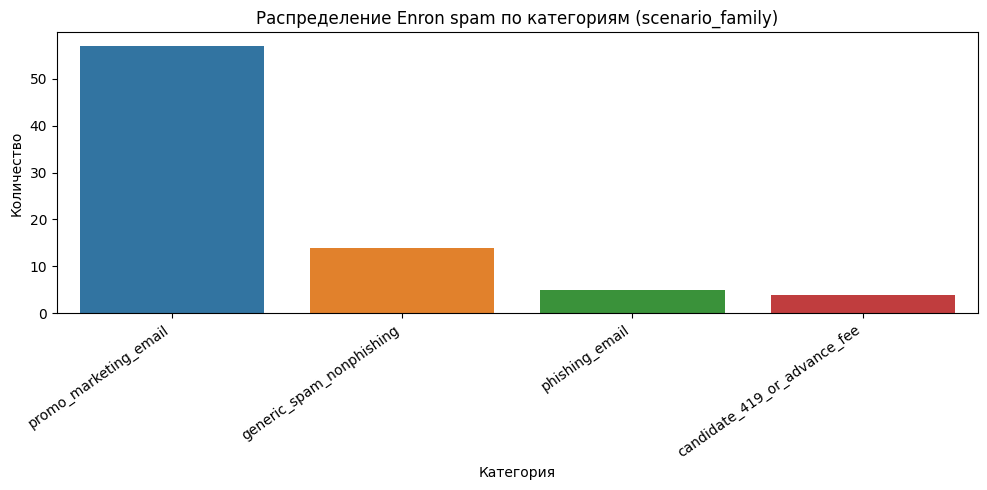


Примеры аннотированных писем для разных категорий:

Категория: promo_marketing_email
Confidence: high
Текст: v
america ' s # 1 government grant program !
the federal government gives away billions of dollars in grants each every year ( free
money ! )
take advantage of this opportunity today and change your life
forever !
30 day money back guarantee !
can ' t wait on the mail ?
you can receive our fabulous grant guide book in one easy download ! start searching for grants in minutes ! simply order your grant guide book today by sending
$ 21 . 95 cash , check or money order with your e - mail address enclosed to :
government grants loans
p . o . box 101262
cape coral fl 33910
free cash grants are being funded by the
u . s . government and private foundations each and every day . these grants are funded from your tax dollars . the private foundations use the grants as a tax write - off ! this free money can be used for any purpose you can imagine . start a business , go to college , buy 

In [9]:
# --- Компактная визуализация статистики по Enron spam ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

rows = ac.load_jsonl(OUT_FLAT)
print(f"Total annotated: {len(rows)}")

# Категории и confidence
df = pd.DataFrame(rows)
cat_counts = df['scenario_family'].fillna("unclear_other").value_counts()
conf_counts = df['annotation_confidence'].fillna("low").value_counts()

print("\nCategory distribution:")
print(cat_counts)
print("\nConfidence distribution:")
print(conf_counts)

possible_flags = [
    "core_candidate",
    "has_financial_pretence",
    "has_credentials_request",
    "has_reward_or_prize",
    "has_confidentiality_appeal"
]
print("\nFlag counts (True per flag):")
for flag in possible_flags:
    print(f"{flag:30s}: {df[flag].astype(bool).sum()}")

plt.figure(figsize=(10, 5))
sns.barplot(x=cat_counts.index, y=cat_counts.values, palette="tab10")
plt.title("Распределение Enron spam по категориям (scenario_family)")
plt.ylabel("Количество")
plt.xlabel("Категория")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print("\nПримеры аннотированных писем для разных категорий:\n")
for cat in cat_counts.index[:4]:
    example = df.loc[df['scenario_family'] == cat].iloc[0]
    print(f"Категория: {cat}")
    print(f"Confidence: {example.get('annotation_confidence')}")
    print(f"Текст: {example.get('text','')}")
    flags = {f: example.get(f) for f in possible_flags if pd.notna(example.get(f))}
    if flags:
        print(f"Флаги: {flags}")
    print("-" * 80)
